# Data Analysis – Midterm EDA: Inflation, Interest Rates, and Market Performance

## Introduction

Inflation and interest rates are two important macroeconomic forces affecting financial markets. When inflation rises, it can influence interest rates, company earnings, consumer spending, and investor sentiment, which in turn can impact market performance.

However, the relationship between inflation, interest rates, and the stock market is not always straightforward. Different sectors may respond differently depending on factors such as pricing power, sensitivity to borrowing costs, and exposure to economic growth.

This notebook explores how inflation, interest rates, and equity market performance relate to each other over a ten-year period from **January 2015 through December 2024**. This timeframe captures both a low-inflation pre-COVID environment and the sharp inflation and interest rate increases that followed the pandemic.

## Target Audience

This analysis is intended for investors or market observers who want a clearer understanding of how inflation and interest rates have historically related to market performance. The goal is not to predict the future perfectly, but to identify patterns that can help interpret market behavior during different economic environments.

## Research Questions

1. How has inflation changed over time during the 2015–2024 period?
2. How did broad market ETFs perform during this period?
3. Do certain sectors appear to perform differently during higher vs. lower inflation periods?
4. Are there visible patterns between inflation, interest rates, and market returns?
5. Do inflation and interest rates help explain broad market returns in a simple regression model?

## Scope of Analysis

This notebook focuses on exploratory data analysis (EDA) to identify patterns and relationships between inflation, interest rates, and market performance.

The analysis is descriptive and does not aim to establish causality or statistically significant relationships. Instead, it provides directional insights based on observed trends in the data. These insights should be interpreted as indicative rather than definitive.

Further analysis using more advanced statistical methods or additional data would be required to validate and quantify these relationships.

## Data Sources

| Dataset | Source | Coverage |
|---|---|---|
| Consumer Price Index (CPIAUCSL) | FRED API | Jan 2015 – Dec 2024, monthly |
| Federal Funds Rate (FEDFUNDS) | FRED API | Jan 2015 – Dec 2024, monthly |
| Broad Market ETFs | Yahoo Finance chart API | Jan 2015 – Dec 2024, monthly |
| Sector ETFs | Yahoo Finance chart API | Jan 2015 – Dec 2024, monthly |

## ETF Overview
 
### Broad Market ETFs
 
- **SPY** — Tracks the S&P 500 (500 large-cap U.S. companies). The most traded ETF in the world, offering broad exposure to the U.S. economy.
- **QQQ** — Tracks the Nasdaq-100 (100 largest non-financial Nasdaq companies). Heavily weighted toward tech giants like Apple, Microsoft, Nvidia, and Meta.
- **DIA** — Tracks the Dow Jones Industrial Average (30 blue-chip U.S. companies like Boeing, Goldman Sachs, and Johnson & Johnson).

### Sector ETFs (SPDR Select Sector Series)
 
These carve the S&P 500 into individual sectors:
 
| Ticker | Sector | Key Holdings |
|--------|------------------------|----------------------------------------------|
| XLE | Energy | ExxonMobil, Chevron |
| XLF | Financials | JPMorgan, Berkshire Hathaway, Visa |
| XLK | Technology | Apple, Microsoft, Nvidia |
| XLU | Utilities | NextEra Energy, Duke Energy |
| XLP | Consumer Staples | Procter & Gamble, Coca-Cola, Walmart |
| XLY | Consumer Discretionary | Amazon, Tesla, Home Depot |
| XLB | Materials | Linde, Sherwin-Williams, Air Products |
| XLI | Industrials | GE Aerospace, Caterpillar, Union Pacific |
| XLV | Health Care | UnitedHealth, Johnson & Johnson, Eli Lilly |

## Analytical Approach

The analysis is structured in the following steps:

1. **Data collection**  
   CPI and Federal Funds Rate data are retrieved using the FRED API, and ETF price data is collected using the Yahoo Finance chart API.

2. **Data cleaning and validation**  
   The dataset is checked for missing values, correct data types, duplicates, and unusual observations.

3. **Feature creation**  
   New variables are created, including CPI year-over-year inflation, month-over-month inflation, inflation regimes, COVID-period flags, and ETF returns.

4. **Exploratory data analysis (EDA)**  
   Inflation, interest rates, and market performance are visualized and compared across time and economic environments.

5. **Basic regression analysis**  
   A simple linear regression is used to examine whether inflation and interest rates help explain broad market returns.

## Why This Matters

Inflation and interest rates play key roles in shaping financial markets. By comparing macroeconomic indicators with broad market and sector performance, this analysis helps provide context for how different parts of the market may react during changing economic conditions.


## 1. Import libraries

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests
import time
from datetime import datetime
import seaborn as sns

## 2. Download CPI data from the FRED API

In [77]:
FRED_API_KEY = "b37dc26c81cedf5337f95e307bfd8497"

fred_url = "https://api.stlouisfed.org/fred/series/observations"

fred_params = {
    "series_id": "CPIAUCSL",
    "api_key": FRED_API_KEY,
    "file_type": "json",
    "observation_start": "2015-01-01",
    "observation_end": "2024-12-31",
    "frequency": "m"
}

fred_response = requests.get(fred_url, params=fred_params)
print("FRED status code:", fred_response.status_code)

fred_data = fred_response.json()

FRED status code: 200


## 3. Create and clean the CPI dataframe

In [78]:
cpi = pd.DataFrame(fred_data["observations"])

cpi = cpi[["date", "value"]]

# Rename columns so they are easier to understand
cpi = cpi.rename(columns={"date": "Date", "value": "CPI"})

# Convert data types
cpi["Date"] = pd.to_datetime(cpi["Date"])
cpi["CPI"] = pd.to_numeric(cpi["CPI"], errors="coerce")

cpi.head()

,Date,CPI
0,2015-01-01,234.747
1,2015-02-01,235.342
2,2015-03-01,235.976
3,2015-04-01,236.222
4,2015-05-01,237.001


## 4. Data quality checks for CPI

In [79]:
print("Rows and columns:", cpi.shape)
print("\nMissing values:")
print(cpi.isna().sum())

print("\nDuplicate dates:", cpi["Date"].duplicated().sum())

print("\nCPI summary:")
print(cpi["CPI"].describe())

print("\nFirst date:", cpi["Date"].min())
print("Last date:", cpi["Date"].max())

Rows and columns: (120, 2)

Missing values:
Date    0
CPI     0
dtype: int64

Duplicate dates: 0

CPI summary:
count    120.000000
mean     266.973700
std       26.410624
min      234.747000
25%      244.230500
50%      257.098500
75%      294.924000
max      317.604000
Name: CPI, dtype: float64

First date: 2015-01-01 00:00:00
Last date: 2024-12-01 00:00:00


## Data Quality Interpretation

The CPI dataset appears to be clean and reliable for analysis.

- **Missing values:** There are no missing values in either the date or CPI columns, which means no imputation or data filling is required.
- **Duplicates:** There are no duplicate dates, confirming that the dataset contains one observation per month as expected.
- **Date range:** The dataset spans from January 2015 to December 2024, providing a complete 10-year period that includes both low-inflation and high-inflation environments.
- **Value checks:** CPI values are all positive and fall within a reasonable range (approximately 235 to 318), which is consistent with known CPI trends over this time period.

## Key Takeaway

Overall, the dataset passes all major quality checks and is suitable for exploratory analysis. No major data cleaning adjustments are required, allowing us to proceed confidently to feature creation and analysis.

## 5. Download Federal Funds Rate data from the FRED API

In addition to CPI, we download the Federal Funds Rate from FRED. This adds an interest rate variable to the analysis and helps connect inflation with monetary policy.

In [80]:
fed_params = {
    "series_id": "FEDFUNDS",
    "api_key": FRED_API_KEY,
    "file_type": "json",
    "observation_start": "2015-01-01",
    "observation_end": "2024-12-31",
    "frequency": "m"
}

fed_response = requests.get(fred_url, params=fed_params)
fed_data = fed_response.json()

fed = pd.DataFrame(fed_data["observations"])
fed = fed[["date", "value"]]

# Rename columns so they are easier to understand
fed = fed.rename(columns={"date": "Date", "value": "FedFundsRate"})

# Convert data types
fed["Date"] = pd.to_datetime(fed["Date"])
fed["FedFundsRate"] = pd.to_numeric(fed["FedFundsRate"], errors="coerce")

fed.head()

,Date,FedFundsRate
0,2015-01-01,0.11
1,2015-02-01,0.11
2,2015-03-01,0.11
3,2015-04-01,0.12
4,2015-05-01,0.12


## 6. Data quality checks for Federal Funds Rate

In [81]:
print("Rows and columns:", fed.shape)
print("Missing values:")
print(fed.isna().sum())

print("Duplicate dates:", fed["Date"].duplicated().sum())

print("Federal Funds Rate summary:")
print(fed["FedFundsRate"].describe())

print("Date range:")
print(fed["Date"].min(), "to", fed["Date"].max())

Rows and columns: (120, 2)
Missing values:
Date            0
FedFundsRate    0
dtype: int64
Duplicate dates: 0
Federal Funds Rate summary:
count    120.000000
mean       1.782583
std        1.873314
min        0.050000
25%        0.127500
50%        1.155000
75%        2.402500
max        5.330000
Name: FedFundsRate, dtype: float64
Date range:
2015-01-01 00:00:00 to 2024-12-01 00:00:00


## Data Quality Interpretation

The Federal Funds Rate dataset contains 120 monthly observations from 2015–2024 with no missing values or duplicate dates. Summary statistics indicate substantial variation in interest rates over the sample period, reflecting changing monetary policy conditions before and after the COVID inflation shock.

- **Missing values:** No missing observations were identified before merging with CPI and ETF data.
- **Duplicates:** Duplicate date checks confirm one observation per month.
- **Date range:** The data covers the full 2015–2024 analysis period.
- **Value checks:** Interest rate values were successfully converted to numeric percentages.

## Takeaway

This dataset can be merged with CPI and ETF returns to analyze how interest rate environments interact with inflation and market performance.

## 7. Create inflation features

In [82]:
# Year-over-year inflation compares each month to the same month one year earlier
cpi["CPI_YoY"] = cpi["CPI"].pct_change(12) * 100

# Month-over-month inflation compares each month to the prior month
cpi["CPI_MoM"] = cpi["CPI"].pct_change(1) * 100

# Simple inflation category
cpi["Inflation_Regime"] = pd.cut(
    cpi["CPI_YoY"],
    bins=[-np.inf, 2, 4, np.inf],
    labels=["Low (<2%)", "Moderate (2-4%)", "High (>4%)"]
)

# COVID / post-COVID inflation period flag
cpi["COVID_Period"] = cpi["Date"].between("2020-01-01", "2023-12-31")

cpi.tail()

,Date,CPI,CPI_YoY,CPI_MoM,Inflation_Regime,COVID_Period
115,2024-08-01,314.062,2.607144,0.157222,Moderate (2-4%),False
116,2024-09-01,314.732,2.426483,0.213334,Moderate (2-4%),False
117,2024-10-01,315.631,2.578844,0.285640,Moderate (2-4%),False
118,2024-11-01,316.528,2.719472,0.284193,Moderate (2-4%),False
119,2024-12-01,317.604,2.870691,0.339938,Moderate (2-4%),False


## 8. Plot CPI year-over-year inflation

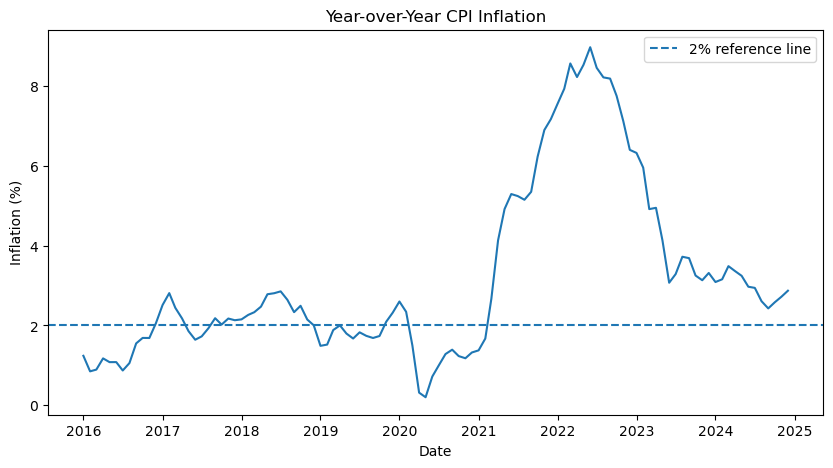

In [83]:
plt.figure(figsize=(10, 5))
plt.plot(cpi["Date"], cpi["CPI_YoY"])
plt.axhline(2, linestyle="--", label="2% reference line")
plt.title("Year-over-Year CPI Inflation")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.legend()
plt.show()

## Interpretation

From 2015 to 2019, inflation remained relatively stable and close to the Federal Reserve’s 2% target, indicating a low and predictable inflation environment. In 2020, inflation dropped briefly, likely reflecting reduced economic activity during the COVID-19 pandemic.

Beginning in 2021, inflation increased sharply, peaking around 8–9% in 2022, the highest levels in decades, before gradually declining through 2023 and 2024. However, inflation remains above the 2% target for most of the later period.

## Takeaway

Overall, the data shows a clear shift from a stable, low-inflation environment to a high-inflation shock and partial normalization. This variation provides a useful backdrop for analyzing how markets and sectors performed under different inflation conditions.

## 9. Download ETF prices from Yahoo Finance API

In [84]:
tickers = [
    "SPY", "QQQ", "DIA",        # broad market ETFs
    "XLE", "XLF", "XLK", "XLU", "XLP", "XLY", "XLB", "XLI", "XLV"  # sector ETFs
]

start_date = datetime(2015, 1, 1)
end_date = datetime(2024, 12, 31)

period1 = int(start_date.timestamp())
period2 = int(end_date.timestamp())

headers = {"User-Agent": "Mozilla/5.0"}
price_data = {}

for ticker in tickers:
    yahoo_url = f"https://query1.finance.yahoo.com/v8/finance/chart/{ticker}"
    yahoo_params = {
        "interval": "1mo",
        "period1": period1,
        "period2": period2
    }

    response = requests.get(yahoo_url, params=yahoo_params, headers=headers)
    result = response.json()["chart"]["result"][0]

    dates = pd.to_datetime(result["timestamp"], unit="s").to_period("M").to_timestamp()
    prices = result["indicators"]["adjclose"][0]["adjclose"]

    price_data[ticker] = pd.Series(prices, index=dates)

    time.sleep(0.25)

etf_prices = pd.DataFrame(price_data)
etf_prices.index.name = "Date"

etf_prices.head()

,SPY,QQQ,DIA,XLE,XLF,XLK,XLU,XLP,XLY,XLB,XLI,XLV
Date,,,,,,,,,,,,
2015-01-01,165.172684,92.972961,136.471954,24.269529,15.142862,17.483944,16.817553,35.620609,30.912312,19.025942,44.624962,57.589920
2015-02-01,174.456207,99.686165,144.348373,25.384228,16.024710,18.881790,15.742095,37.096760,33.553493,20.541954,47.012806,60.059124
2015-03-01,170.953125,97.111244,141.858307,24.921640,15.866771,18.158768,15.463654,36.154686,33.279667,19.460794,45.606262,60.275284
2015-04-01,173.404846,99.205681,142.584488,26.740423,15.939204,18.734680,15.511743,36.099953,33.373711,20.191153,45.700817,59.785263
2015-05-01,175.634186,101.436287,144.222977,25.352953,16.249662,19.082270,15.609965,36.413418,33.812424,20.267239,45.848694,62.478180


## 10. Data quality checks for ETF prices

In [119]:
print("Rows and columns:", etf_prices.shape)
print("\nMissing values by ETF:")
print(etf_prices.isna().sum())

print("\nDuplicate dates:", etf_prices.index.duplicated().sum())

print("\nPrice summary:")
etf_prices.describe()

Rows and columns: (120, 12)

Missing values by ETF:
SPY    0
QQQ    0
DIA    0
XLE    0
XLF    0
XLK    0
XLU    0
XLP    0
XLY    0
XLB    0
XLI    0
XLV    0
dtype: int64

Duplicate dates: 0

Price summary:


,SPY,QQQ,DIA,XLE,XLF,XLK,XLU,XLP,XLY,XLB,XLI,XLV
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,310.086943,237.590308,250.317525,26.857853,26.511973,51.145480,24.682682,53.507960,61.502627,29.284005,76.008369,94.523196
std,115.196708,118.656828,80.298939,8.604062,8.405878,28.689130,6.098171,12.800157,21.338731,8.741744,24.445204,28.968823
min,160.180420,92.972961,131.401367,11.203827,14.148547,17.457710,14.543574,35.437569,30.912312,15.801010,41.188820,55.406754
25%,213.688545,134.630692,183.457134,21.735564,20.583415,26.085639,19.535416,42.228026,41.284684,22.142499,57.658672,68.749308
50%,273.294830,197.782318,235.269531,23.703714,24.302440,41.795446,24.860700,50.649845,56.969524,25.481018,69.480293,86.850708
75%,399.913536,330.431732,316.388580,33.291473,33.108228,72.444918,29.373505,66.170807,79.257027,38.207233,94.833874,122.503468
max,591.941956,507.191956,439.537903,45.539032,50.162365,115.807510,39.704628,79.947227,110.779892,46.587833,140.931015,152.587753


## Data Quality Interpretation

The ETF dataset appears clean and consistent for analysis.

- **Missing values:** There are no missing values across the ETFs, indicating complete data for the selected time period.
- **Duplicates:** No duplicate dates were found, confirming one observation per month.
- **Data coverage:** All ETFs have 120 observations, matching the 10-year monthly timeframe (2015–2024).
- **Value checks:** Price ranges and summary statistics appear reasonable, with no obvious anomalies or invalid values.

## Takeaway

Overall, the ETF data passes key quality checks and is suitable for analysis. Removing newer ETFs with incomplete histories ensures consistency across all sectors when comparing performance.

## 11. Create return features and combine CPI, interest rates, and ETF returns

In [86]:
# Monthly returns show percent change in ETF prices from one month to the next
monthly_returns = etf_prices.pct_change() * 100

# 12-month returns are easier to compare to year-over-year inflation
annual_returns = etf_prices.pct_change(12) * 100

# Join CPI, Federal Funds Rate, and ETF return data
cpi_for_merge = cpi.set_index("Date")[["CPI_YoY", "CPI_MoM", "Inflation_Regime", "COVID_Period"]]
fed_for_merge = fed.set_index("Date")[["FedFundsRate"]]

analysis_data = cpi_for_merge.join(fed_for_merge, how="inner")
analysis_data = analysis_data.join(annual_returns, how="inner")

# Drop rows where annual returns, CPI_YoY, or FedFundsRate are missing
analysis_data = analysis_data.dropna()

analysis_data.head()

,CPI_YoY,CPI_MoM,Inflation_Regime,COVID_Period,FedFundsRate,SPY,QQQ,DIA,XLE,XLF,XLK,XLU,XLP,XLY,XLB,XLI,XLV
Date,,,,,,,,,,,,,,,,,
2016-01-01,1.237503,-0.045844,Low (<2%),False,0.34,-0.868620,4.039864,-1.897745,-20.624316,-3.775194,5.244407,-2.499501,8.496145,7.424048,-16.950182,-6.450789,-2.681758
2016-02-01,0.847278,-0.132968,Low (<2%),False,0.38,-6.221306,-4.485421,-6.868879,-26.235013,-11.707935,-3.185031,6.179563,4.507248,-0.591165,-17.067707,-7.418774,-7.019723
2016-03-01,0.891616,0.313480,Low (<2%),False,0.36,1.613618,4.456072,1.855268,-17.814535,-4.867428,8.999610,15.842289,11.736940,6.500995,-6.156652,1.570720,-5.184945
2016-04-01,1.172626,0.383065,Low (<2%),False,0.37,1.090471,-0.714092,2.100388,-15.865052,-1.455078,0.845102,13.537635,10.870433,6.772821,-4.598838,3.147920,-1.219964
2016-05-01,1.078476,0.236410,Low (<2%),False,0.37,1.505235,1.346009,1.047854,-12.088917,-1.513222,3.849337,14.524211,10.672628,5.440715,-5.279869,2.375871,-3.364706


## SQL Upload/Formatting

In [87]:
import sqlite3

# Create an in-memory SQLite database
conn = sqlite3.connect(":memory:")

# Load your existing DataFrames as SQL tables
analysis_data.reset_index().to_sql("macro", conn, index=False, if_exists="replace")

# Create the long-format etf_returns table by melting analysis_data
etf_tickers = ["SPY", "QQQ", "DIA", "XLE", "XLF", "XLK", "XLU", "XLP", "XLY", "XLB", "XLI", "XLV"]
etf_returns = analysis_data[etf_tickers].reset_index().melt(
    id_vars="Date", var_name="Ticker", value_name="AnnualReturn"
)

# Use .map() to add a readable sector name for each ticker
ticker_to_sector = {
    "SPY": "S&P 500", "QQQ": "Nasdaq-100", "DIA": "Dow Jones",
    "XLE": "Energy", "XLF": "Financials", "XLK": "Technology",
    "XLU": "Utilities", "XLP": "Consumer Staples", "XLY": "Consumer Discretionary",
    "XLB": "Materials", "XLI": "Industrials", "XLV": "Health Care"
}
etf_returns["Sector"] = etf_returns["Ticker"].map(ticker_to_sector)

etf_returns.to_sql("etf_returns", conn, index=False, if_exists="replace")

# Create the etf_metadata lookup table
etf_metadata = pd.DataFrame({
    "Ticker": ["SPY", "QQQ", "DIA", "XLE", "XLF", "XLK", "XLU", "XLP", "XLY", "XLB", "XLI", "XLV"],
    "Sector": ["S&P 500", "Nasdaq-100", "Dow Jones", "Energy", "Financials", "Technology",
                "Utilities", "Consumer Staples", "Consumer Discretionary", "Materials", "Industrials", "Health Care"],
    "ETF_Type": ["Broad", "Broad", "Broad", "Sector", "Sector", "Sector",
                 "Sector", "Sector", "Sector", "Sector", "Sector", "Sector"]
})
etf_metadata.to_sql("etf_metadata", conn, index=False, if_exists="replace")

print("Tables created: macro, etf_returns, etf_metadata")

Tables created: macro, etf_returns, etf_metadata


In [120]:
# Helper function to run SQL queries and return results as DataFrames
def run_query(sql):
    return pd.read_sql_query(sql, conn)

## SQL Query 1: Combined Dataset Validation
What: Counts observations per inflation regime and shows the date range for each.

How: Joins etf_returns, macro, and etf_metadata to confirm all three tables linked correctly after the Section 11 merge.

Why: Validates that the combined dataset has sufficient observations across Low, Moderate, and High inflation regimes to support meaningful comparisons.

In [89]:
result = run_query("""
    SELECT
        m.Inflation_Regime,
        COUNT(DISTINCT e.Ticker) AS NumETFs,
        COUNT(*)                 AS NumObservations,
        MIN(e.Date)              AS EarliestDate,
        MAX(e.Date)              AS LatestDate
    FROM etf_returns e
    JOIN macro m ON e.Date = m.Date
    JOIN etf_metadata md ON e.Ticker = md.Ticker
    GROUP BY m.Inflation_Regime
    ORDER BY m.Inflation_Regime
""")
result

,Inflation_Regime,NumETFs,NumObservations,EarliestDate,LatestDate
0,High (>4%),12,312,2021-04-01 00:00:00,2023-05-01 00:00:00
1,Low (<2%),12,432,2016-01-01 00:00:00,2021-02-01 00:00:00
2,Moderate (2-4%),12,552,2016-12-01 00:00:00,2024-12-01 00:00:00


## 12. Data quality checks for the combined dataset

In [90]:
print("Rows and columns:", analysis_data.shape)

print("\nMissing values:")
print(analysis_data.isna().sum())

print("\nNumber of months in each inflation regime:")
print(analysis_data["Inflation_Regime"].value_counts())

print("\nSample of final analysis data:")
analysis_data.head()

Rows and columns: (108, 17)

Missing values:
CPI_YoY             0
CPI_MoM             0
Inflation_Regime    0
COVID_Period        0
FedFundsRate        0
SPY                 0
QQQ                 0
DIA                 0
XLE                 0
XLF                 0
XLK                 0
XLU                 0
XLP                 0
XLY                 0
XLB                 0
XLI                 0
XLV                 0
dtype: int64

Number of months in each inflation regime:
Inflation_Regime
Moderate (2-4%)    46
Low (<2%)          36
High (>4%)         26
Name: count, dtype: int64

Sample of final analysis data:


,CPI_YoY,CPI_MoM,Inflation_Regime,COVID_Period,FedFundsRate,SPY,QQQ,DIA,XLE,XLF,XLK,XLU,XLP,XLY,XLB,XLI,XLV
Date,,,,,,,,,,,,,,,,,
2016-01-01,1.237503,-0.045844,Low (<2%),False,0.34,-0.868620,4.039864,-1.897745,-20.624316,-3.775194,5.244407,-2.499501,8.496145,7.424048,-16.950182,-6.450789,-2.681758
2016-02-01,0.847278,-0.132968,Low (<2%),False,0.38,-6.221306,-4.485421,-6.868879,-26.235013,-11.707935,-3.185031,6.179563,4.507248,-0.591165,-17.067707,-7.418774,-7.019723
2016-03-01,0.891616,0.313480,Low (<2%),False,0.36,1.613618,4.456072,1.855268,-17.814535,-4.867428,8.999610,15.842289,11.736940,6.500995,-6.156652,1.570720,-5.184945
2016-04-01,1.172626,0.383065,Low (<2%),False,0.37,1.090471,-0.714092,2.100388,-15.865052,-1.455078,0.845102,13.537635,10.870433,6.772821,-4.598838,3.147920,-1.219964
2016-05-01,1.078476,0.236410,Low (<2%),False,0.37,1.505235,1.346009,1.047854,-12.088917,-1.513222,3.849337,14.524211,10.672628,5.440715,-5.279869,2.375871,-3.364706


## Data Quality Interpretation

The combined dataset appears clean and well-structured for analysis.

- **Missing values:** There are no missing values across CPI, Federal Funds Rate, ETF returns, or engineered features after rows with incomplete return data are removed.
- **Alignment:** All variables are aligned at the monthly level, allowing consistent comparisons between inflation, interest rates, and market data.
- **Inflation regimes:** The data is distributed across low, moderate, and high inflation periods, allowing for comparisons across different environments.
- **Feature checks:** Engineered features such as inflation regime and COVID period appear correctly assigned.

## Takeaway

The dataset is complete and consistent, with sufficient variation across inflation and interest rate environments to support exploratory analysis of how markets and sectors behave under different conditions.

## SQL Query 2: Inflation Regime Distribution
What: Counts how many months fall into each inflation regime.

How: Simple GROUP BY on the Inflation_Regime column in the macro table.

Why: Confirms there are enough months in each regime before using regime as a grouping variable throughout the EDA. Mirrors the .value_counts() check done in Python.

In [91]:
result = run_query("""
    SELECT
        Inflation_Regime,
        COUNT(*) AS MonthCount
    FROM macro
    GROUP BY Inflation_Regime
    ORDER BY Inflation_Regime
""")
result

,Inflation_Regime,MonthCount
0,High (>4%),26
1,Low (<2%),36
2,Moderate (2-4%),46


## 13. Checking for and dealing with outliers

To check for outliers, we looked at monthly returns and defined outliers as any months with returns outside of 3 standard deviations from the mean.

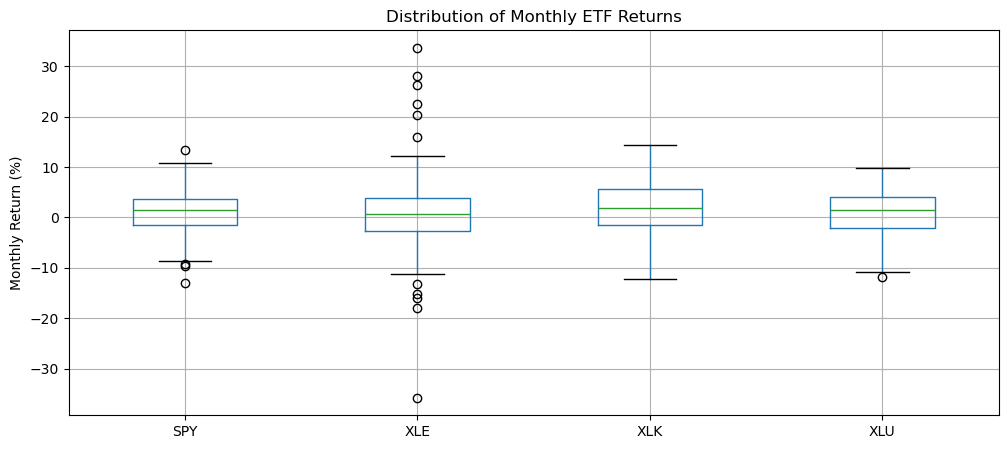

Extreme SPY months (beyond 3 std devs):
                 SPY
Date                
2020-03-01 -12.99871

Extreme XLE months (beyond 3 std devs):
                  XLE
Date                 
2020-03-01 -35.807377
2020-04-01  33.690028
2020-11-01  27.994435

Extreme XLK months (beyond 3 std devs):
Empty DataFrame
Columns: [XLK]
Index: []

Extreme XLU months (beyond 3 std devs):
Empty DataFrame
Columns: [XLU]
Index: []



In [92]:
monthly_returns_clean = etf_prices.pct_change() * 100

# Create the chart.
plt.figure(figsize=(12, 5))
monthly_returns_clean[["SPY", "XLE", "XLK", "XLU"]].boxplot()
plt.title("Distribution of Monthly ETF Returns")
plt.ylabel("Monthly Return (%)")
plt.xticks(rotation=0)
plt.show()

# Show which months are extreme
threshold = 3  # standard deviations
for ticker in ["SPY", "XLE", "XLK", "XLU"]:
    ticker_mean = monthly_returns_clean[ticker].mean()
    ticker_std = monthly_returns_clean[ticker].std()

    outliers = monthly_returns_clean[
        (monthly_returns_clean[ticker] < ticker_mean - threshold * ticker_std) |
        (monthly_returns_clean[ticker] > ticker_mean + threshold * ticker_std)
    ]
    print(f"Extreme {ticker} months (beyond 3 std devs):")
    print(outliers[[ticker]])
    print()

## Interpretation
XLU and XLK don't have any months with extreme outliers. SPY has one, March 2020, and XLE has three, March, April, and November of 2020. While these dates are all extreme outliers, we know they represent real market events during COVID, not data errors. Thus, we didn't remove them from the dataset.

## Takeaway
The dataset does not feature unexplainable extreme outliers that would distort analysis.

## 14. Feature Engineering

To support the analysis, we created a few additional variables:

- **CPI_YoY:** Main measure of year-over-year inflation trends  
- **CPI_MoM:** Short-term monthly inflation changes  
- **FedFundsRate:** Captures the interest rate environment and changes in monetary policy  
- **Inflation_Regime:** Groups inflation into low, moderate, and high environments  
- **COVID_Period:** Flags the COVID-era observations  

These features allow us to compare market behavior across different inflation conditions, interest rate environments, and time periods.

# Exploratory Data Analysis (EDA)

This section examines how market and sector returns vary across inflation environments and time periods, using the engineered features above.

## 15. Correlation Overview

Before diving into specific analyses, we first look at overall relationships between inflation and market returns using a correlation heatmap.

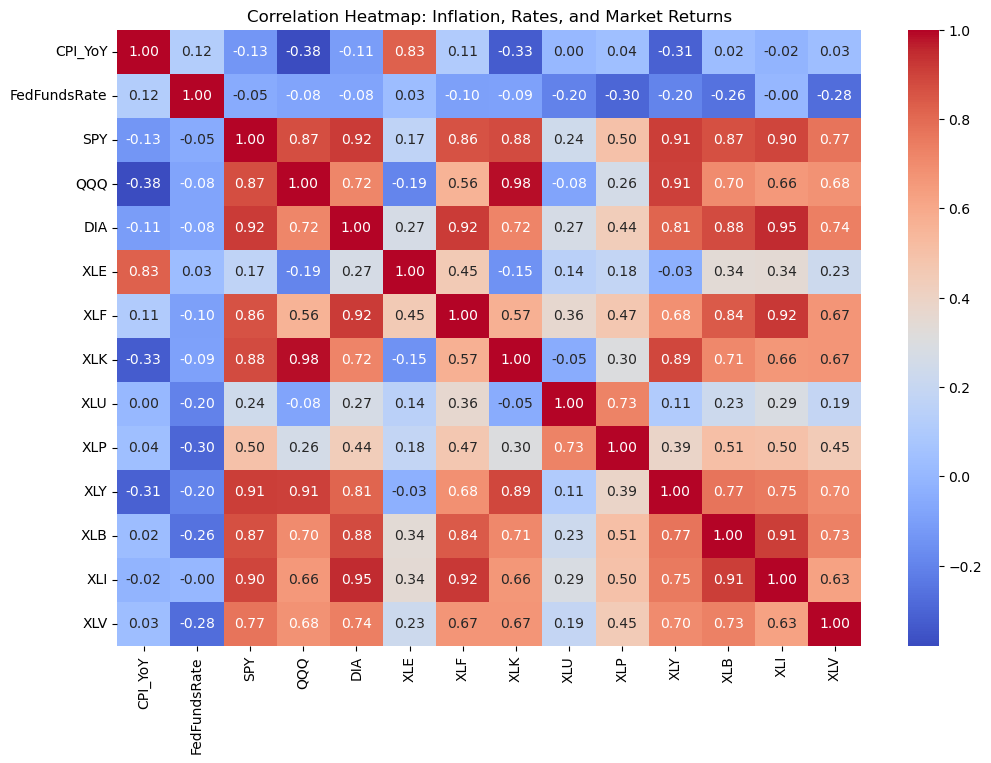

In [93]:
corr_data = analysis_data[['CPI_YoY', 'FedFundsRate', 'SPY', 'QQQ', 'DIA', 'XLE', 'XLF', 'XLK', 'XLU', 'XLP', 'XLY', 'XLB', 'XLI', 'XLV']]
corr_matrix = corr_data.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: Inflation, Rates, and Market Returns")
plt.show()

### Interpretation

The heatmap shows the correlation between inflation, interest rates, and ETF returns. Inflation and the Federal Funds Rate exhibit a positive relationship, which is expected because interest rates often rise during periods of elevated inflation.

The analysis also reveals meaningful differences across sectors. Energy-related ETFs such as XLE show a strong positive relationship with inflation, while growth-oriented sectors such as technology (XLK) and QQQ display more negative relationships. This suggests that some sectors may benefit from inflationary environments while others are more negatively impacted.

At the same time, inflation and interest rates do not show a strong linear relationship with overall market returns across the full dataset. Most ETFs remain highly correlated with each other, indicating that broad market movements still play an important role across sectors.

### Takeaway

The heatmap suggests that inflation and interest rates are connected to broader market behavior, but their impact varies across sectors and market environments. In particular, energy-related sectors appear more resilient during higher inflation periods, while growth-oriented sectors appear more sensitive to inflation and rising rates.

## SQL Query 3: Average Inflation and Fed Funds Rate by Regime
What: Shows the average CPI_YoY and Fed Funds Rate for each inflation regime.

How: Groups the macro table by Inflation_Regime and averages both macro variables.

Why: Adds a numeric anchor to the correlation heatmap, confirming that higher inflation regimes correspond with higher interest rates and supporting the positive correlation observed in Section 15.

In [94]:
result = run_query("""
    SELECT
        Inflation_Regime,
        ROUND(AVG(CPI_YoY), 2)      AS AvgInflation,
        ROUND(AVG(FedFundsRate), 2) AS AvgFedFundsRate
    FROM macro
    GROUP BY Inflation_Regime
    ORDER BY AvgInflation
""")
result

,Inflation_Regime,AvgInflation,AvgFedFundsRate
0,Low (<2%),1.36,0.84
1,Moderate (2-4%),2.67,2.99
2,High (>4%),6.64,1.71


## 16. Inflation and Interest Rates Over Time

This visualization compares year-over-year inflation and the Federal Funds Rate over time. It helps show how monetary policy changed during different inflation environments.

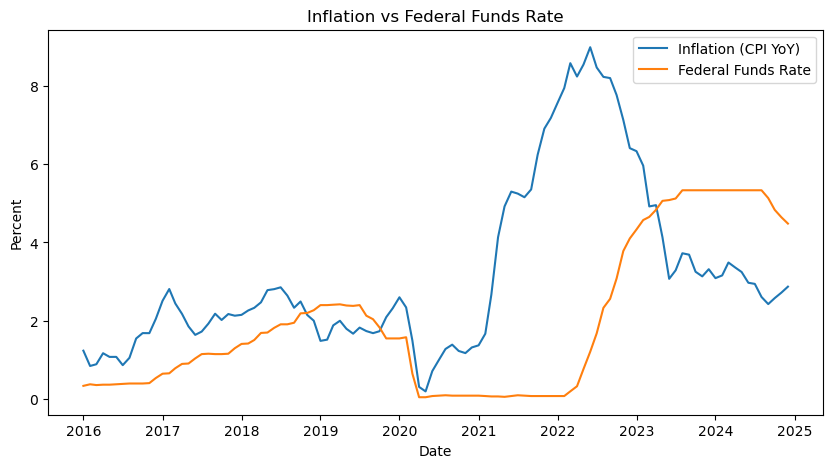

In [95]:
plt.figure(figsize=(10, 5))

plt.plot(analysis_data.index, analysis_data["CPI_YoY"], label="Inflation (CPI YoY)")
plt.plot(analysis_data.index, analysis_data["FedFundsRate"], label="Federal Funds Rate")

plt.title("Inflation vs Federal Funds Rate")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.legend()
plt.show()

Average SPY, QQQ, and DIA return by rate environment which complements the inflation regime analysis by showing 
how broad market returns differ across low, moderate, and high interest rate environments

In [96]:
def classify_rate_env(rate):
    if rate < 1.0:
        return "Low (<1%)"
    elif rate <= 3.0:
        return "Moderate (1-3%)"
    else:
        return "High (>3%)"

analysis_data["Rate_Environment"] = analysis_data["FedFundsRate"].apply(classify_rate_env)

analysis_data["Rate_Environment"].value_counts()

rate_env_returns = analysis_data.groupby("Rate_Environment")[["SPY", "QQQ", "DIA"]].mean().round(2)
rate_env_returns

,SPY,QQQ,DIA
Rate_Environment,,,
High (>3%),14.69,19.68,11.71
Low (<1%),16.98,24.93,13.66
Moderate (1-3%),10.81,15.55,12.69


### Interpretation

The chart shows that inflation and the Federal Funds Rate moved closely together during the 2021–2023 period. Inflation increased sharply following the post-COVID economic recovery and supply chain disruptions, reaching its highest levels in decades. In response, the Federal Reserve raised interest rates aggressively beginning in 2022. The figure also highlights the lagged relationship between inflation and monetary policy: inflation began rising before the Federal Funds Rate responded significantly, reflecting the delayed policy response typical in macroeconomic management.

The rate environment table adds further context. Broad market ETFs actually performed best during low rate environments (<1%), with QQQ averaging 24.93% and SPY averaging 16.98%. Performance during high rate environments (>3%) remained solid but lower, while moderate rate environments (1–3%) were associated with the weakest returns across all three broad ETFs, likely reflecting the period of uncertainty as rates were actively rising.

### Takeaway

Monetary policy tightened in response to elevated inflation, but the relationship between rate levels and market returns is not straightforward. The strongest returns occurred during the low-rate post-financial-crisis environment, while the transition period of rising rates appears to have created the most headwinds for equity markets. This suggests that rate direction and uncertainty may matter as much as rate levels themselves. We explore that dynamic further in the regression analysis in Section 22.

## SQL Query 4: Months Where the Fed Was Behind the Curve
What: Identifies months where inflation was above the high-inflation average but the Fed Funds Rate was still below 2%.

How: Uses a WHERE-clause subquery to dynamically calculate the average CPI_YoY during high inflation periods, then filters for months where rates hadn't yet responded.

Why: Directly supports the Section 16 finding that inflation rose before the Fed responded by isolating exactly those months as a concrete data point.

In [97]:
result = run_query("""
    SELECT
        Date,
        CPI_YoY,
        FedFundsRate
    FROM macro
    WHERE CPI_YoY > (SELECT AVG(CPI_YoY) FROM macro WHERE Inflation_Regime = 'High (>4%)')
      AND FedFundsRate < 2.0
    ORDER BY Date
""")
result

,Date,CPI_YoY,FedFundsRate
0,2021-11-01 00:00:00,6.901970,0.08
1,2021-12-01 00:00:00,7.174340,0.08
2,2022-01-01 00:00:00,7.558806,0.08
3,2022-02-01 00:00:00,7.937279,0.08
4,2022-03-01 00:00:00,8.572205,0.20
5,2022-04-01 00:00:00,8.231751,0.33
6,2022-05-01 00:00:00,8.538171,0.77
7,2022-06-01 00:00:00,8.979361,1.21
8,2022-07-01 00:00:00,8.462577,1.68


## 17. Normalizing CPI and ETF Returns for Comparison

Since ETF returns vary by a greater amount than inflation/CPI, normalizing these variables and rescaling each variable to a 0-1 range makes it much easier to visually compare trends while maintaining the shape of each trend.

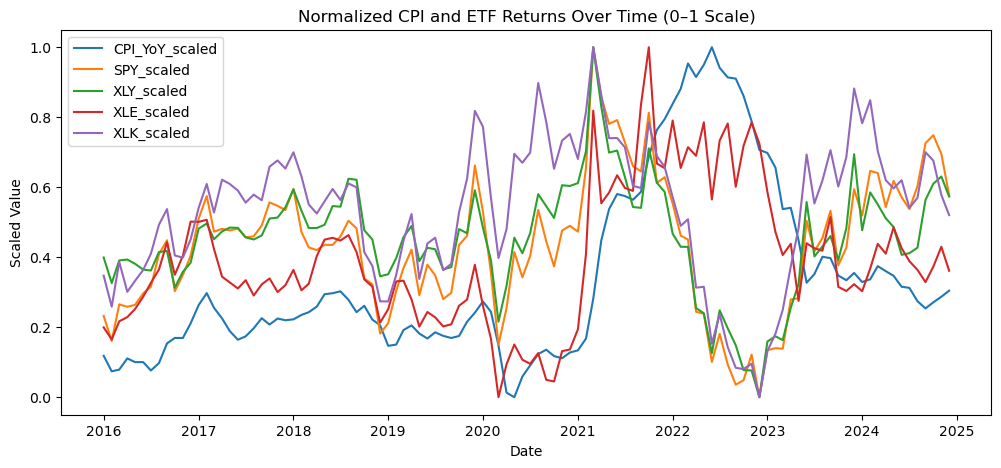

In [98]:
from sklearn.preprocessing import MinMaxScaler

# Scale CPI_YoY and a few ETF annual returns to 0–1 range
cols_to_scale = ["CPI_YoY", "SPY", "XLY", "XLE", "XLK"]
scaler = MinMaxScaler()

normalized = pd.DataFrame(
    scaler.fit_transform(analysis_data[cols_to_scale]),
    columns=[c + "_scaled" for c in cols_to_scale],
    index=analysis_data.index
)

# Plot normalized values on same axis to compare trends
plt.figure(figsize=(12, 5))
for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col)
plt.title("Normalized CPI and ETF Returns Over Time (0–1 Scale)")
plt.xlabel("Date")
plt.ylabel("Scaled Value")
plt.legend()
plt.show()

### Interpretation

We can see multiple patterns when comparing the normalized trends:

- **CPI (blue):** inflation rises sharply beginning in 2021, peaks in 2022, then generally declines through 2024, consistent with the COVID surge.
- **XLE (green):** energy sector performance generally moves alongside inflation during the high-inflation period, which aligns with the strong positive correlation observed earlier in the analysis.
- **XLK (red) & XLY (orange):** tech & consumer spending trend opposite of CPI & XLE. When inflation spiked between 2020-2022, tech stocks and consumer spending plummeted. As inflation cooled after its peak in 2022, tech stocks and consumer spending rebounded, with tech being more volatile across the period. These sectors appear more sensitive during periods of elevated inflation and rising interest rates.

### Takeaway

Normalization helps compare trends across variables measured on different scales. The figure suggests that different market sectors responded differently during changing inflation environments, with energy appearing more positively aligned with inflation trends while technology and consumer-focused sectors experienced greater pressure during periods of elevated inflation and tightening monetary policy.

## SQL Query 5: Side-by-Side Annual Returns for SPY, XLE, and XLK
What: Shows the 12-month annual return for SPY, XLE, and XLK in a single row per month.

How: Uses CASE statements inside MAX() to pivot the long-format etf_returns table into a wide format with one column per ticker.

Why: Before normalizing in Python, this confirms that these three ETFs move differently over time. The divergence between XLE and XLK during the high-inflation period is visible in the raw data.

In [99]:
result = run_query("""
    SELECT
        e.Date,
        MAX(CASE WHEN e.Ticker = 'SPY' THEN ROUND(e.AnnualReturn, 2) END) AS SPY,
        MAX(CASE WHEN e.Ticker = 'XLE' THEN ROUND(e.AnnualReturn, 2) END) AS XLE,
        MAX(CASE WHEN e.Ticker = 'XLK' THEN ROUND(e.AnnualReturn, 2) END) AS XLK
    FROM etf_returns e
    GROUP BY e.Date
    ORDER BY e.Date
""")
result

,Date,SPY,XLE,XLK
0,2016-01-01 00:00:00,-0.87,-20.62,5.24
1,2016-02-01 00:00:00,-6.22,-26.24,-3.19
2,2016-03-01 00:00:00,1.61,-17.81,9.00
3,2016-04-01 00:00:00,1.09,-15.87,0.85
4,2016-05-01 00:00:00,1.51,-12.09,3.85
...,...,...,...,...
103,2024-08-01 00:00:00,26.92,6.09,26.40
104,2024-09-01 00:00:00,36.10,0.39,38.79
105,2024-10-01 00:00:00,37.81,7.57,36.51
106,2024-11-01 00:00:00,33.81,16.83,27.17


## 18. Average ETF return by inflation regime

In [100]:
return_columns = tickers

regime_returns = analysis_data.groupby("Inflation_Regime")[return_columns].mean()
regime_returns

,SPY,QQQ,DIA,XLE,XLF,XLK,XLU,XLP,XLY,XLB,XLI,XLV
Inflation_Regime,,,,,,,,,,,,
Low (<2%),9.008843,19.218935,6.829812,-15.586482,0.846194,20.835443,10.471280,9.215288,11.435037,5.419899,5.157091,7.558758
Moderate (2-4%),20.511036,28.964479,18.993759,9.329237,20.964517,31.153452,8.899727,6.994390,19.871272,14.237531,19.392089,11.951991
High (>4%),10.611081,6.890521,10.277689,52.253967,17.709325,11.726559,9.930851,10.156431,4.250297,13.210357,13.251197,11.637496


<Figure size 1000x500 with 0 Axes>

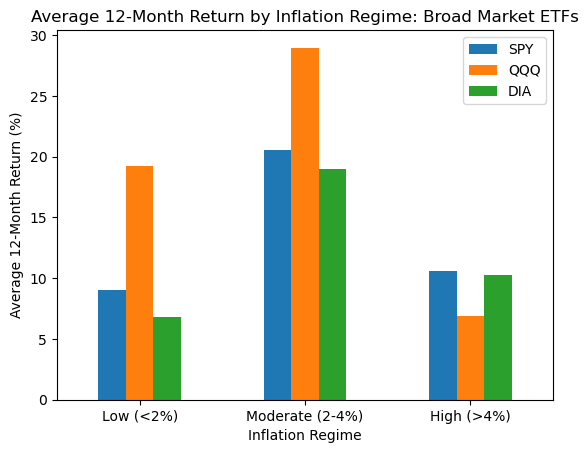

In [101]:
plt.figure(figsize=(10, 5))
regime_returns[["SPY", "QQQ", "DIA"]].plot(kind="bar")
plt.title("Average 12-Month Return by Inflation Regime: Broad Market ETFs")
plt.xlabel("Inflation Regime")
plt.ylabel("Average 12-Month Return (%)")
plt.xticks(rotation=0)
plt.show()

### Interpretation

Average returns differ meaningfully across inflation regimes.

- Returns are generally highest during **moderate inflation (2–4%)**, particularly for growth-oriented ETFs like QQQ.
- During **low inflation** (<2%), returns remain positive but are generally lower than during moderate inflation periods.
- In **high inflation (>4%)**, environments, returns weaken for some assets, with QQQ showing the largest decline relative to the moderate inflation regime.
- SPY and DIA appear more stable across inflation regimes, while QQQ demonstrates greater sensitivity to changing macroeconomic conditions.

### Takeaway

The results suggest that moderate inflation environments were associated with stronger market performance during the sample period, while elevated inflation corresponded with weaker performance for growth-oriented assets. This supports the broader analysis that inflation conditions may influence sector and market behavior differently across asset classes.

## SQL Query 6: Average Broad Market ETF Return by Inflation Regime
What: Shows the average 12-month return for SPY, QQQ, and DIA broken out by inflation regime.

How: Joins etf_returns, macro, and etf_metadata, filters to broad market ETFs, and groups by regime and ticker.

Why: Uses SQL to create an equivalent of the Section 18 bar chart, confirming that moderate inflation is associated with the strongest broad market returns and that QQQ is the most sensitive to regime changes.

In [102]:
result = run_query("""
    SELECT
        m.Inflation_Regime,
        e.Ticker,
        ROUND(AVG(e.AnnualReturn), 2) AS AvgAnnualReturn
    FROM etf_returns e
    JOIN macro m ON e.Date = m.Date
    JOIN etf_metadata md ON e.Ticker = md.Ticker
    WHERE md.ETF_Type = 'Broad'
    GROUP BY m.Inflation_Regime, e.Ticker
    ORDER BY m.Inflation_Regime, e.Ticker
""")
result

,Inflation_Regime,Ticker,AvgAnnualReturn
0,High (>4%),DIA,10.28
1,High (>4%),QQQ,6.89
2,High (>4%),SPY,10.61
3,Low (<2%),DIA,6.83
4,Low (<2%),QQQ,19.22
5,Low (<2%),SPY,9.01
6,Moderate (2-4%),DIA,18.99
7,Moderate (2-4%),QQQ,28.96
8,Moderate (2-4%),SPY,20.51


## 19. Sector performance during high inflation

In [103]:
high_inflation = analysis_data[analysis_data["Inflation_Regime"] == "High (>4%)"]

sector_columns = ["XLE", "XLF", "XLK", "XLU", "XLP", "XLY", "XLB", "XLI", "XLV"]

high_inflation_sector_avg = high_inflation[sector_columns].mean().sort_values(ascending=False)

high_inflation_sector_avg

XLE    52.253967
XLF    17.709325
XLI    13.251197
XLB    13.210357
XLK    11.726559
XLV    11.637496
XLP    10.156431
XLU     9.930851
XLY     4.250297
dtype: float64

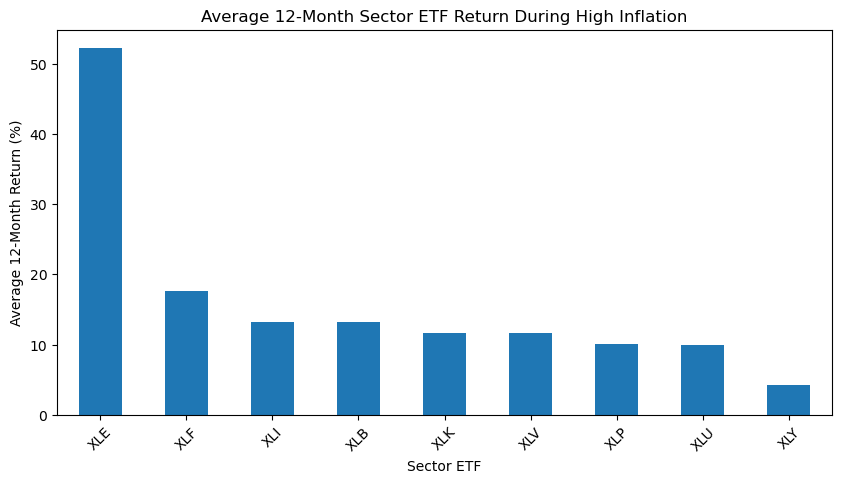

In [104]:
plt.figure(figsize=(10, 5))
high_inflation_sector_avg.plot(kind="bar")
plt.title("Average 12-Month Sector ETF Return During High Inflation")
plt.xlabel("Sector ETF")
plt.ylabel("Average 12-Month Return (%)")
plt.xticks(rotation=45)
plt.show()

### Interpretation

Sector performance varies during high inflation periods.

- Energy (XLE) shows the highest average returns compared to other sectors during elevated inflation environments.
- Financials (XLF) and industrials (XLI) also perform relatively well.
- Consumer-oriented sectors such as XLY show weaker performance during high inflation.

One possible explanation is that energy price shocks can contribute to inflationary pressure throughout the economy. Rising oil and energy prices increase transportation and production costs, which may support energy-sector revenues while placing pressure on consumer-focused industries.

### Takeaway

The results suggest that inflation does not affect all sectors equally. Energy-related sectors appear more resilient during high inflation periods, while consumer-sensitive sectors may face greater challenges as costs rise and purchasing power weakens.

## SQL Query 7: Sector ETFs That Outperformed SPY by Inflation Regime
What: Shows which sector ETFs beat SPY's average return within each inflation regime.

How: Self-joins etf_returns to bring SPY in as a benchmark on each date, then uses HAVING to filter to only sectors that beat SPY on average.

Why: Extends the Section 18 analysis from "how did sectors perform" to "which sectors actually beat the broad market", which is a more actionable insight for investors.

In [105]:
result = run_query("""
    SELECT
        e.Ticker,
        md.Sector,
        ROUND(AVG(e.AnnualReturn), 2) AS AvgReturn,
        RANK() OVER (ORDER BY AVG(e.AnnualReturn) DESC) AS ReturnRank
    FROM etf_returns e
    JOIN macro m ON e.Date = m.Date
    JOIN etf_metadata md ON e.Ticker = md.Ticker
    WHERE m.Inflation_Regime = 'High (>4%)'
      AND md.ETF_Type = 'Sector'
    GROUP BY e.Ticker, md.Sector
    ORDER BY ReturnRank
""")
result

,Ticker,Sector,AvgReturn,ReturnRank
0,XLE,Energy,52.25,1
1,XLF,Financials,17.71,2
2,XLI,Industrials,13.25,3
3,XLB,Materials,13.21,4
4,XLK,Technology,11.73,5
5,XLV,Health Care,11.64,6
6,XLP,Consumer Staples,10.16,7
7,XLU,Utilities,9.93,8
8,XLY,Consumer Discretionary,4.25,9


## SQL Query 8: Sector ETF Return Ranking During High Inflation
What: Ranks all sector ETFs by average annual return during high inflation periods, from best to worst.

How: Filters to high inflation months, joins to etf_metadata for sector labels, and uses RANK() window function to order sectors by performance.

Why: created an SQL version of the Section 19 bar chart to make the ranking explicit and confirm that Energy (XLE) leads while consumer-facing sectors lag during elevated inflation.

In [106]:
result = run_query("""
    SELECT
        m.Inflation_Regime,
        e.Ticker,
        md.Sector,
        ROUND(AVG(e.AnnualReturn), 2) AS AvgSectorReturn,
        ROUND(AVG(spy.AnnualReturn), 2) AS AvgSPY_Return
    FROM etf_returns e
    JOIN macro m ON e.Date = m.Date
    JOIN etf_metadata md ON e.Ticker = md.Ticker
    JOIN etf_returns spy ON spy.Date = e.Date AND spy.Ticker = 'SPY'
    WHERE md.ETF_Type = 'Sector'
    GROUP BY m.Inflation_Regime, e.Ticker, md.Sector
    HAVING AVG(e.AnnualReturn) > AVG(spy.AnnualReturn)
    ORDER BY m.Inflation_Regime, AvgSectorReturn DESC
""")
result

,Inflation_Regime,Ticker,Sector,AvgSectorReturn,AvgSPY_Return
0,High (>4%),XLE,Energy,52.25,10.61
1,High (>4%),XLF,Financials,17.71,10.61
2,High (>4%),XLI,Industrials,13.25,10.61
3,High (>4%),XLB,Materials,13.21,10.61
4,High (>4%),XLK,Technology,11.73,10.61
5,High (>4%),XLV,Health Care,11.64,10.61
6,Low (<2%),XLK,Technology,20.84,9.01
7,Low (<2%),XLY,Consumer Discretionary,11.44,9.01
8,Low (<2%),XLU,Utilities,10.47,9.01
9,Low (<2%),XLP,Consumer Staples,9.22,9.01


## 20. Relationship between inflation and SPY returns

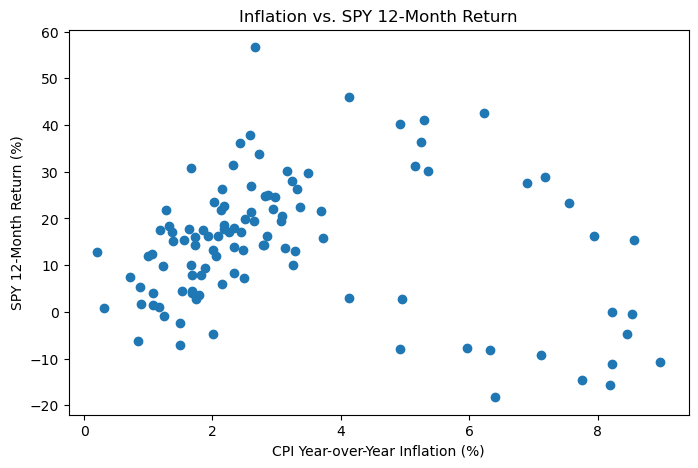

Correlation between CPI_YoY and SPY 12-month return: -0.13


In [107]:
plt.figure(figsize=(8, 5))
plt.scatter(analysis_data["CPI_YoY"], analysis_data["SPY"])
plt.title("Inflation vs. SPY 12-Month Return")
plt.xlabel("CPI Year-over-Year Inflation (%)")
plt.ylabel("SPY 12-Month Return (%)")
plt.show()

correlation = analysis_data["CPI_YoY"].corr(analysis_data["SPY"])
print("Correlation between CPI_YoY and SPY 12-month return:", round(correlation, 2))

### Interpretation

The scatter plot shows a weak negative relationship between inflation and SPY 12-month returns.

- The correlation coefficient (-0.13) indicates only a slight negative linear relationship between inflation and market performance.
- Market returns appear more volatile and dispersed during higher inflation environments.
- Several periods of elevated inflation are associated with weaker or negative SPY returns, although the relationship is not consistent across all observations.

### Takeaway

The analysis suggests that inflation alone does not fully explain equity market performance. While higher inflation environments may create headwinds for broad equity markets, other macroeconomic and market factors also play significant roles in determining returns.

## 21. COVID-period comparison

In [108]:
covid_comparison = analysis_data.groupby("COVID_Period")[["CPI_YoY", "SPY", "QQQ", "DIA"]].mean()
covid_comparison

,CPI_YoY,SPY,QQQ,DIA
COVID_Period,,,,
False,2.121209,15.086412,20.021687,15.302795
True,4.518981,13.302696,20.877084,9.763299


### Interpretation

Comparing COVID and non-COVID periods highlights meaningful differences in both inflation and equity market performance.

- Average inflation increased substantially during the COVID period, rising from approximately 2.1% to 4.5%.
- Broad market performance weakened slightly during the COVID period, with SPY average returns declining from 15.1% to 13.3%.
- Growth-oriented technology stocks (QQQ) remained relatively resilient and slightly outperformed during the COVID period.
- More traditional large-cap industrial stocks (DIA) experienced a more noticeable decline in returns during the COVID environment.

### Takeaway

The COVID period represents a unique macroeconomic regime characterized by elevated inflation, supply chain disruptions, aggressive monetary policy changes, and uneven sector performance. The results reinforce the importance of analyzing market behavior across different economic environments rather than relying only on long-run averages.

## SQL Query 9: COVID vs. Non-COVID Macro and SPY Return Comparison
What: Compares average inflation, Fed Funds Rate, and SPY return between COVID-period and non-COVID-period months.

How: Uses a FROM-clause subquery to pre-filter etf_returns to SPY only, then joins to macro and aggregates by COVID_Period flag.

Why: Directly supports the Section 21 COVID comparison analysis by surfacing how dramatically the macro environment and market returns differed between the two periods in a single summary table.

In [109]:
result = run_query("""
    SELECT
        covid.COVID_Period,
        ROUND(AVG(covid.CPI_YoY), 2)      AS AvgInflation,
        ROUND(AVG(covid.FedFundsRate), 2) AS AvgFedRate,
        ROUND(AVG(covid.AnnualReturn), 2) AS AvgSPY_Return
    FROM (
        SELECT m.COVID_Period, m.CPI_YoY, m.FedFundsRate, e.AnnualReturn
        FROM etf_returns e
        JOIN macro m ON e.Date = m.Date
        WHERE e.Ticker = 'SPY'
    ) AS covid
    GROUP BY covid.COVID_Period
""")
result

,COVID_Period,AvgInflation,AvgFedRate,AvgSPY_Return
0,0,2.12,2.11,15.09
1,1,4.52,1.79,13.30


## 22. Average returns for each sector ETF grouped by year

Shows how sector performance evolved year-over-year across the full sample period

In [110]:
sector_columns = ["XLE", "XLF", "XLK", "XLU", "XLP", "XLY", "XLB", "XLI", "XLV"]

yearly_sector_returns = analysis_data.groupby(
    analysis_data.index.year
)[sector_columns].mean().round(2)

yearly_sector_returns

,XLE,XLF,XLK,XLU,XLP,XLY,XLB,XLI,XLV
Date,,,,,,,,,
2016,-2.41,1.92,9.34,15.42,10.70,4.81,2.21,7.44,-1.26
2017,5.48,31.30,29.16,12.20,7.04,16.71,21.53,23.68,14.07
2018,7.82,11.63,22.92,1.95,-0.30,20.25,6.28,10.06,13.36
2019,-9.75,3.90,16.13,19.67,13.48,11.25,2.33,6.67,7.82
2020,-34.60,-7.23,36.47,3.99,8.37,14.75,6.11,-1.32,13.13
2021,49.11,49.78,42.65,11.52,16.41,38.31,42.67,38.49,25.45
2022,62.71,-0.92,-4.08,12.13,9.24,-11.73,-0.39,-2.56,6.00
2023,13.57,0.85,21.05,-5.83,0.68,4.72,4.94,11.14,1.58
2024,10.28,30.02,33.69,16.00,10.84,20.60,13.78,24.92,13.55


## 23. Multiple Linear Regression Analysis

To extend the analysis beyond exploratory visualization, a simple linear regression was used to examine whether inflation and interest rates help explain broad market returns.

In [111]:
!pip3 install statsmodels
import statsmodels.api as sm

X = analysis_data[["CPI_YoY", "FedFundsRate"]]
X = sm.add_constant(X)

y = analysis_data["SPY"]

model = sm.OLS(y, X).fit()

print(model.summary())

Defaulting to user installation because normal site-packages is not writeable
                            OLS Regression Results                            
Dep. Variable:                    SPY   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.012
Date:                Mon, 25 May 2026   Prob (F-statistic):              0.367
Time:                        23:39:08   Log-Likelihood:                -437.71
No. Observations:                 108   AIC:                             881.4
Df Residuals:                     105   BIC:                             889.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

### Interpretation

A multiple linear regression was used to examine whether inflation and interest rates help explain SPY returns.

- Both CPI inflation and the Federal Funds Rate have negative coefficients, suggesting that higher inflation and tighter monetary policy are associated with slightly weaker market performance.
- However, neither variable is statistically significant at conventional confidence levels based on the p-values.
- The model's R-squared value is very low (approximately 0.02), indicating that inflation and interest rates explain only a small portion of SPY return variation.
- The Durbin-Watson statistic is 0.28, well below the ideal value of 2.0, indicating strong positive autocorrelation in the residuals. This is expected when using 12-month rolling returns measured at a monthly frequency because each consecutive observation shares 11 of 12 months of underlying data with the prior observation. As a result, the standard errors may be understated and the p-values should be interpreted with caution. For the purposes of this exploratory analysis, the directional finding remains useful: inflation and interest rates alone have limited explanatory power for broad market returns.

### Takeaway

The regression results suggest that equity market returns are influenced by many factors beyond inflation and monetary policy alone. While macroeconomic conditions matter, broader market performance also depends on earnings growth, investor sentiment, economic shocks, and other financial variables.

## SQL Query 10: Month-over-Month Fed Funds Rate Change with Inflation Context
What: Shows each month's Fed Funds Rate, the change from the prior month, CPI_YoY, and inflation regime.

How: Uses the LAG() window function to calculate the month-over-month change in the Fed Funds Rate relative to the prior month.

Why: Supports the Section 22 regression analysis by isolating the rate-change variable used as a predictor and makes the Fed's tightening cycle visible row by row and helps explain why rate changes may matter more than rate levels for market returns.

In [112]:
result = run_query("""
    SELECT
        Date,
        FedFundsRate,
        FedFundsRate - LAG(FedFundsRate) OVER (ORDER BY Date) AS FedRate_Change,
        CPI_YoY,
        Inflation_Regime
    FROM macro
    ORDER BY Date
""")
result

,Date,FedFundsRate,FedRate_Change,CPI_YoY,Inflation_Regime
0,2016-01-01 00:00:00,0.34,NaN,1.237503,Low (<2%)
1,2016-02-01 00:00:00,0.38,0.04,0.847278,Low (<2%)
2,2016-03-01 00:00:00,0.36,-0.02,0.891616,Low (<2%)
3,2016-04-01 00:00:00,0.37,0.01,1.172626,Low (<2%)
4,2016-05-01 00:00:00,0.37,0.00,1.078476,Low (<2%)
...,...,...,...,...,...
103,2024-08-01 00:00:00,5.33,0.00,2.607144,Moderate (2-4%)
104,2024-09-01 00:00:00,5.13,-0.20,2.426483,Moderate (2-4%)
105,2024-10-01 00:00:00,4.83,-0.30,2.578844,Moderate (2-4%)
106,2024-11-01 00:00:00,4.64,-0.19,2.719472,Moderate (2-4%)


## 24. Logistic Regression Analysis

Predicting whether a month is a high inflation period using Fed Funds Rate and ETF returns Binary target: 1 = High inflation (>4%), 0 = everything else

In [113]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


analysis_data["HighInflation"] = (analysis_data["Inflation_Regime"] == "High (>4%)").astype(int)

X_log = analysis_data[["FedFundsRate", "SPY", "XLE", "XLK"]]
y_log = analysis_data["HighInflation"]

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_log, y_log)
y_pred = log_model.predict(X_log)

print("Accuracy:", round(accuracy_score(y_log, y_pred), 2))
print("\nClassification Report:")
print(classification_report(y_log, y_pred))

Accuracy: 0.94

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        82
           1       0.92      0.85      0.88        26

    accuracy                           0.94       108
   macro avg       0.93      0.91      0.92       108
weighted avg       0.94      0.94      0.94       108



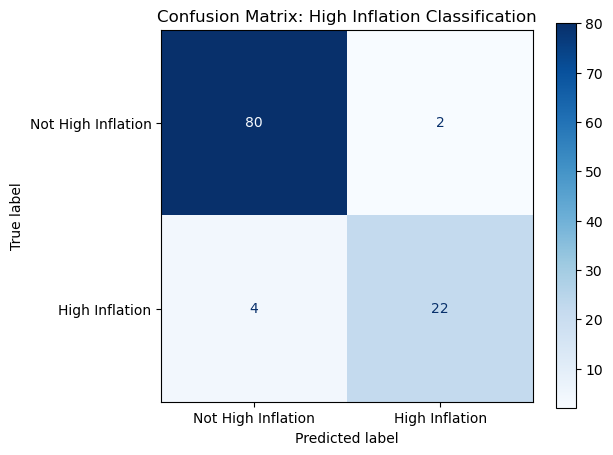

In [114]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix for the logistic regression model
cm = confusion_matrix(y_log, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not High Inflation", "High Inflation"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues")
plt.title("Confusion Matrix: High Inflation Classification")
plt.show()

### Interpretation
The logistic regression uses the Fed Funds Rate and a selection of ETF returns to predict whether a given month falls in a high inflation period. This reuses the same variables explored throughout the EDA. If XLE and FedFundsRate are strong predictors, it quantitatively supports the correlations observed in Section 15.

The confusion matrix shows the model correctly identified 22 of 26 high-inflation months and 80 of 82 non-high-inflation months. The four missed high-inflation months likely fall near the 4% boundary where the regime classification is less clear-cut.

### Takeaway
The OLS regression in Section 22 asked "how much do inflation and rates explain SPY returns?", this model flips the question to ask, "can market behavior identify high inflation periods?" Together, the two models approach the inflation-market relationship from opposite directions.

# 25. Conclusion

Overall, the analysis suggests that inflation and interest rates do not exhibit a strong standalone linear relationship with broad market returns, as indicated by the correlation analysis, scatter plots, and multiple regression results.

However, the analysis shows that market behavior still varies meaningfully across different economic environments.

## Key Findings

- Inflation remained relatively stable prior to COVID, increased sharply during 2021–2022, and later moderated.
- Interest rates generally increased alongside elevated inflation, reflecting a tighter monetary policy environment.
- Market performance varies across inflation environments, with moderate inflation associated with the strongest broad market returns.
- Sector performance differs during high inflation periods, with some sectors outperforming others.
- The COVID period represents a distinct economic environment with higher inflation, higher interest rates, and differences in market behavior.
- The simple regression suggests that inflation and interest rates alone have limited explanatory power for broad market returns.

## Implications

These findings suggest that:

- Inflation and interest rate environments are important considerations when evaluating market conditions.
- Sector-level differences become more relevant during periods of elevated inflation and tighter monetary policy.
- Market performance depends on broader economic conditions rather than a single macroeconomic variable alone.

## Limitations

- The analysis is based on historical data and does not establish causality.
- The dataset is limited to CPI, Federal Funds Rate, and ETF returns.
- The regression is intentionally simple and may not capture more complex market dynamics.
- Results are based on monthly data and may not capture shorter-term reactions.

## Next Steps

- Incorporate additional macro variables such as unemployment, GDP growth, or market volatility.
- Explore rolling correlations over time.
- Analyze shorter-term market responses around major inflation and interest rate changes.
- Test more advanced models to better quantify relationships.